In [2]:
import numpy as np
import scanpy as sc
import squidpy as sq
import stan


In [3]:
adata=sc.datasets.visium_sge()
sc.pp.filter_cells(adata, min_counts=2000)
sc.pp.filter_genes(adata, min_cells=adata.n_obs/2)
sc.pp.normalize_total(adata, 20000)
sc.pp.log1p(adata)
sc.pp.scale(adata)

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [1]:
stan.pp.pixel_intensity(adata, window_size=10)
sc.pl.spatial(adata, color=[None, "pixel_intensity"], size=1.5)
sc.pl.spatial(sq.pl.extract(adata, obsm_key='pixel_intensity'), color=["r", "g", "b"], size=1.5)

NameError: name 'stan' is not defined

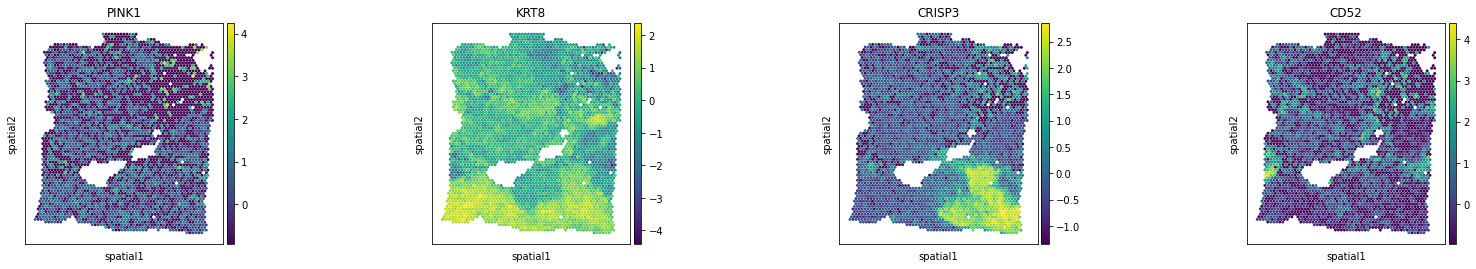

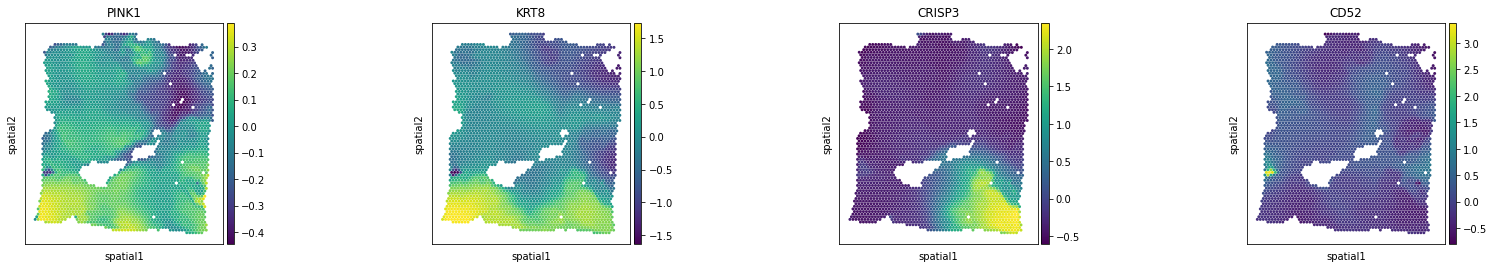

In [5]:
stan.pp.make_kernel(adata, n=500,im_feats_weight=0.15, banwidth=0.25)

adata.layers['spatial']=stan.pp.kernel_smooth(adata.to_df(), adata.obsp['kernel'])

sc.pl.spatial(adata, color=["PINK1", 'KRT8', "CRISP3", "CD52"], alpha_img=0, size=1.5)
sc.pl.spatial(adata, color=["PINK1", 'KRT8', "CRISP3", "CD52"], layer='spatial', alpha_img=0, size=1.5)

adata.var['spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

adata.to_df('spatial')

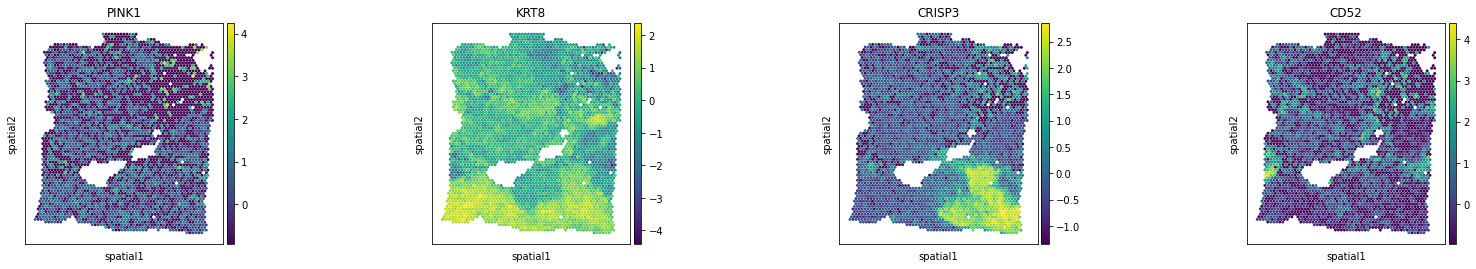

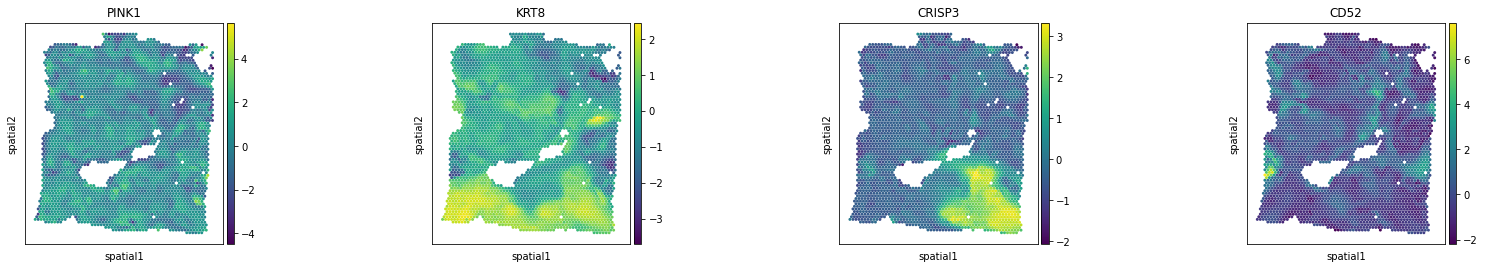

0.45805815592870774


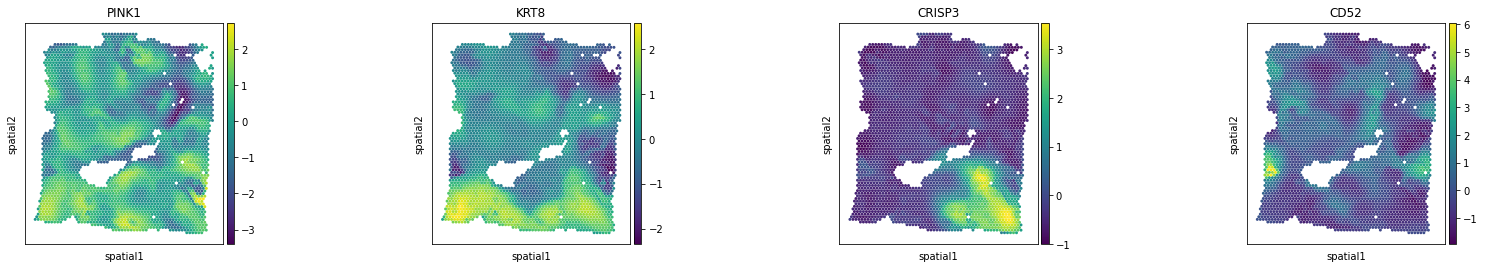

0.34703826599418053

In [6]:
stan.pp.make_kernel(adata, n=500,im_feats_weight=0.15, banwidth=0.25)

Y=adata.to_df()
X=adata.obsm['kernel']

s=((X**2).sum(axis=0))
kernel_proj=X.dot(np.diag(s/(s**2 + 0)).dot(X.T))

adata.layers['spatial']=kernel_proj.dot(Y)
x=adata.layers['spatial'].T
x=(x-x.mean(axis=1).reshape(-1,1))/x.std(axis=1).reshape(-1,1)
adata.layers['spatial']=x.T

adata.var['approx_kernel_spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

sc.pl.spatial(adata, color=["PINK1", 'KRT8', "CRISP3", "CD52"], alpha_img=0, size=1.5)
sc.pl.spatial(adata, color=["PINK1", 'KRT8', "CRISP3", "CD52"], layer='spatial', alpha_img=0, size=1.5)

print(adata.var['approx_kernel_spat_cor'].median())


kernel_proj=X.dot(np.diag(s/(s**2 + 100)).dot(X.T))

adata.layers['spatial']=kernel_proj.dot(Y)
x=adata.layers['spatial'].T
x=(x-x.mean(axis=1).reshape(-1,1))/x.std(axis=1).reshape(-1,1)
adata.layers['spatial']=x.T

adata.var['approx_kernel_spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

sc.pl.spatial(adata, color=["PINK1", 'KRT8', "CRISP3", "CD52"], layer='spatial', alpha_img=0, size=1.5)

adata.var['approx_kernel_spat_cor'].median()